# **Proyecto Flores de Iris**

**1. Descripción y carga del conjunto de datos**

In [ ]:
# El conjunto de datos de iris tiene medidas morfológicas de las tres especies de flores:
# •	Iris setosa
# •	Iris versicolor
# •	Iris virginica

# En cada registro tendremos:
# •	La longitud del sépalo (cm)
# •	La anchura del sépalo (cm)
# •	La longitud del pétalo (cm)
# •	El ancho del pétalo (cm)
# •	La especie (clase/target)

# El Dataset Iris se puede encontrar importando el módulo load_iris de la librería scikit-learn. Todo lo demás es intuitivo. En la consola nos mostrarán los datos relacionados con los valores del iris
# clasificado por columnas. Los datos estarán organizados en un Dataframe (tabla estructurada).

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

# cargar el dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species']= iris.target_names[iris.target]

# Mostrar las primeras filas
print(df.head())




   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


**2. Análisis estadístico y representación gráfica de los datos**

In [ ]:
# Vamos a pasar a realizar el análisis estadístico básico  utilizando la función print(df.describe)()). Con la función print(df[‘species’].value_counts()) nos mostrará cuántas muestras hay de cada tipo.

In [ ]:
print(df.describe())
print("\nDistribución de especies:")
print(df['species'].value_counts())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

Distribución de especies:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
# Con el siguiente código, veremos los gráficos pairplot y boxplots. He utilizado en primer lugar pairplot porque gracias a ello, me permite visualizar con mayor claridad los gráficos y las relaciones
# entre cada par de variables. Mediante boxplot me permite comparar distribuciones entre diferentes categorías (sepal lenght, sepal width, etc) , además de detectar valores atípicos y ver las diferencias
# significativas entre especies para cada característica. Con pairplot.fig.suptitle podremos colocar el título justo encima del gráfico para que no se solape, de lo contrario se me pondría en medio de
# los gráficos (lo he probado anteriormente). En el especifico caso de Boxplot, el bucle for i feature in enumerate (iris.feature_names): itera sobre cada una de las 4 características de las flores iris.
# Con plt.tight_layout() ajustará automáticamente los espacios entre subgráficos. Con plt.show() nos mostrará la figura completa con todos los subgráficos.

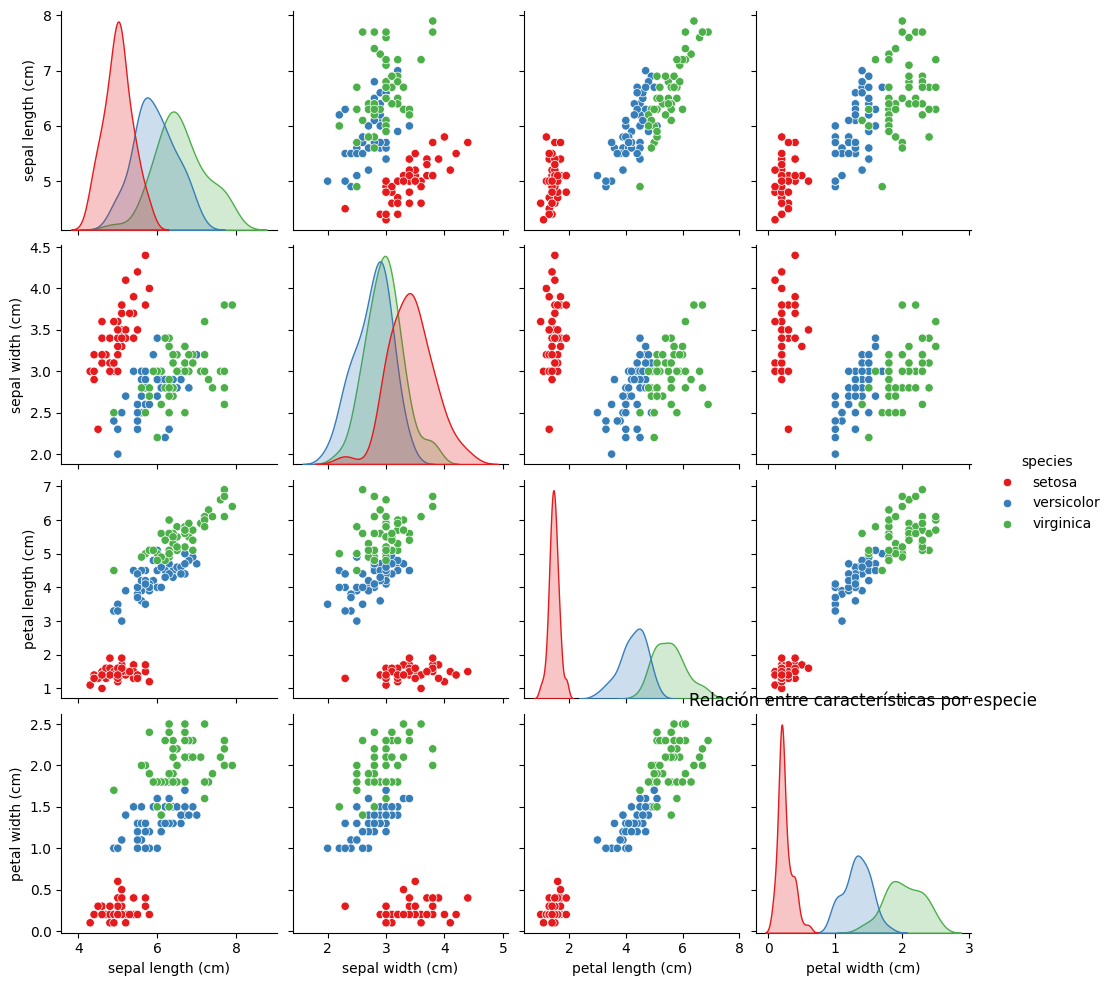

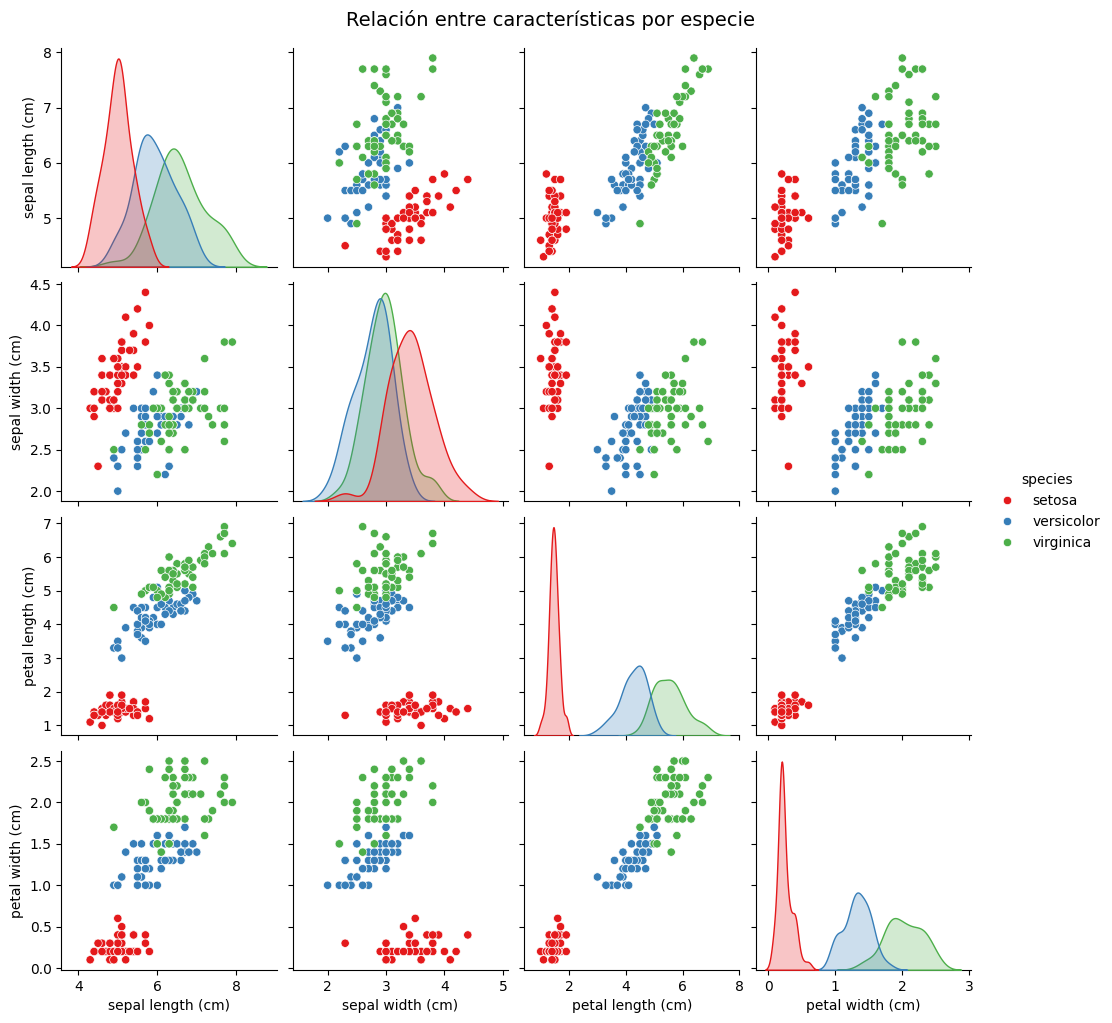

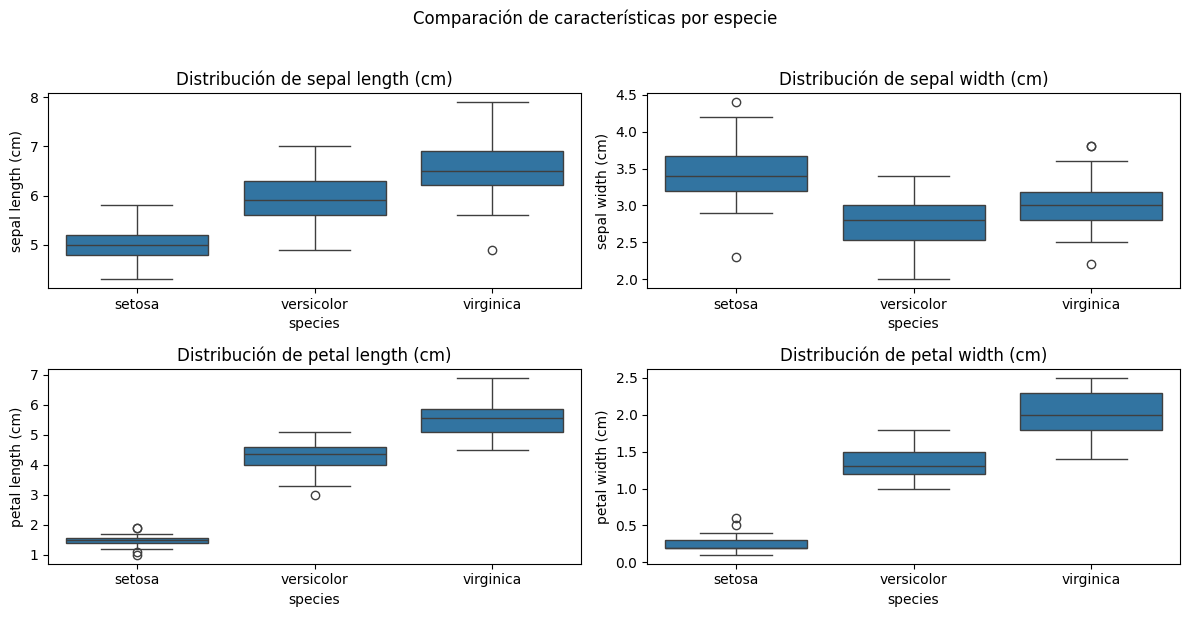

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot para ver relaciones entre variables
sns.pairplot(df, hue='species', palette='Set1')
plt.title('Relación entre características por especie')
plt.show()

#Crearemos el pairplot con el título en la posición correcta
pairplot=sns.pairplot(df, hue='species', palette='Set1')

# Añadiremos el título para que esté encima de los gráficos y no se solape
pairplot.fig.suptitle('Relación entre características por especie', y=1.02, fontsize=14)

# Boxplots por característica
plt.figure(figsize=(12, 6))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='species', y=feature, data=df)
    plt.title(f'Distribución de {feature}')  # Añade título a cada subplot
plt.suptitle('Comparación de características por especie', y=1.02)  # Título general
plt.tight_layout()
plt.show()

**3. Elección de un modelo de clasificación supervisado y descripción del mismo.**

In [ ]:
# A continuación, seleccionaremos el modelo de Support Vector Machine (SVM) por lo siguiente:
# 1. Por lo eficaz que es en conjuntos pequeños. El dataset Iris solo tiene 150 muestras, y SVM funciona especialmente bien con conjuntos de datos de tamaño moderado.
# 2. Por la separabilidad lineal: los datos muestran que algunas especies son linealmente separables (especialmente la Iris setosa).
# 3. Versatilidad: Aunque utilicemos un kernel lineal inicialmente, SVM puede adaptarse a problemas no lineales
# 4. Por el margen de separación: SVM nos va a maximizar el margen entre clases, lo que nos proporcionará una buena generalización. SVM busca encontrar el hiperplano óptimo que:

# • Separe las clases con el mayor margen posible.
# • Minimice el error de clasificación.
# • En problemas no lineales, proyecte los datos a un espacio dimensional superior usando funciones kernel.

# Las ventajas para este caso son:
# • Buen desempeño cuando hay un margen claro de separación.
# • Eficaz en espacios multidimensionales (4 características en Iris).
# • Resistente al overfitting, especialmente con parámetros adecuados.

**4. Entrenamiento, evaluación y validación del modelo supervisado.**

In [ ]:
# Antes de entrenar el modelo, tendremos que dividir el dataset en:
# - Conjunto de entrenamiento (70-80%) para aprender patrones.
# - Conjunto de prueba (20-30%) para evaluar el rendimiento en datos no vistos.
# Configuramos el modelo SVM con parámetros iniciales y lo entrenamos. Usaremos un kernel porque los datos son parcialmente separables linealmente hablando. Con C=1.0 tendremos un parámetro de
# regularización.

In [ ]:
from sklearn.model_selection import train_test_split

X = iris.data # Características (longitud/ancho de sépalos y pétalos)
y = iris.target # Clases (0: setosa, 1: versicolor, 2: virginica)

# Dividir un 70% de entrenamiento y un 30% de prueba
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.3, random_state=42)

from sklearn.svm import SVC

# Creamos el modelo SVM con kernel lineal, lo hacemos así porque los datos son linealmente separables
modelo_svm = SVC (kernel='linear', C=1.0, random_state=42)

In [ ]:
# Evaluaremos el rendimiento del modelo en el conjunto de prueba. Con las métricas de clasificación calcularemos:
# •	Precisión (accuracy): porcentaje de predicciones correctas.
# •	Matriz de confusión: Muestra los aciertos y errores por clase.
# •	Reporte de clasificación: precisión, recall y F1-score por clase.

In [ ]:
# Entrenar el modelo con los datos de entrenamiento
modelo_svm.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predeciremos en el conjunto de prueba
y_pred=modelo_svm.predict(X_test)

# Calcularemos precisión
precision = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {precision*100:.2f}%")

# Matriz de confusión
print ("\n Matriz de confusión:")
print (confusion_matrix(y_test, y_pred))

# Reporte de clasificación
print("\n Reporte de clasificación:")
print (classification_report(y_test, y_pred, target_names=iris.target_names))

from sklearn.model_selection import cross_val_score

# Validación cruzada con 5 folds
scores= cross_val_score(modelo_svm, X, y, cv=5, scoring='accuracy')
print(f"\nPrecisión en validación cruzada: {scores.mean() * 100:.2f}% (±{scores.std() * 100:.2f}%)")

Precisión del modelo: 100.00%

 Matriz de confusión:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

 Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Precisión en validación cruzada: 98.00% (±1.63%)


In [ ]:
# La interpretación de los resultados es que el modelo clasifica correctamente en todas las muestras, ya que tiene una precisión del 100%. La matriz de confusión no da lugar a ningún error.
# Se muestra un buen equilibrio entre precisión y recall. Para asegurar que el modelo no depende de una división específica de datos, usaremos validación cruzada (k-fold). Con una precisión en validación
# cruzada del 98% significa que el modelo generaliza bien, y con una desviación estándar baja , el rendimiento es consistente en diferentes particiones. La precisión es similar en el modelo de prueba
# y en el de entrenamiento por lo tanto, el modelo generaliza bien. La validación cruzada nos muestra que el modelo es robusto y no depende de una partición específica. De esta manera, el modelo
# podríamos decir, que no solo funciona bien en los datos de entrenamiento, sino que también generaliza bien a nuevos datos del modelo en el conjunto de prueba. Con las métricas de clasificación
# calcularemos:
# • Precisión (accuracy): porcentaje de predicciones correctas.
# • Matriz de confusión: Muestra los aciertos y errores por clase.
# • Reporte de clasificación: precisión, recall y F1-score por clase.

**5. Elección de un modelo de clasificación no supervisado.**

In [ ]:
# He seleccionado el algoritmo K-means como algoritmo de clustering no supervisado por las siguientes razones:
# 1. Por su eficacia en conjuntos pequeños y bien estructurados: El dataset Iris tiene solo 150 muestras y 4 características, lo que lo hace ideal para K-means, ya que, este algoritmo funciona mejor
# con los datos de tamaño moderado y baja dimensionalidad.
# 2. Por la separabilidad natural de los clusters: Las especies de Iris (especialmente la setosa) forman grupos compactos y bien diferenciados en el espacio de características, lo que permite que K-means
# identifique los clusters con alta precisión.
# 3. Por la simplicidad y la eficiencia computacional: K-means es rápido y fácil de implementar, lo que lo hace perfecto para un análisis exploratorio inicial. No requiere ajustes complejos más allá de
# especificar el número de clusters (k).
# 4. Interpretabilidad de los resultados: Los centroides obtenidos representan el “corazón” de cada cluster, permitiendo una comprensión intuitiva de las agrupaciones. K-Means es un algoritmo de
# agrupamiento particional que busca dividir un conjunto de datos en k grupos (clusters) de manera que:
# - Los puntos dentro de un mismo cluster sean lo más similares posible (minimizando la varianza intra-cluster).
# - Los puntos de diferentes clusters sean lo más distintos posibles. Las ventajas de K-means con el Dataset Iris son:
# • Tiene clusters bien definidos: Las especies de Iris tienen una separación en el espacio de características, lo que facilita la identificación de grupos naturales.
# • Bajo coste computacional: K-means es eficiente en datasets pequeños como Iris (150 muestras x 4 características).
# • Validación sencilla: Puesto que conocemos las etiquetas reales, (aunque no las utilicemos) podemos comparar los clusters generados con las especies verdaderas usando métricas como el Índice de Rand
# Ajustado (ARI).
# Los inconvenientes son:
# • Elección de k: En este caso, requerirá especificar el número de clústers (en iris, k=3).
# • Sensibilidad a outliers: Los puntos atípicos pueden distorsionar la posición de los centroides.
# • Forma de los clusters: Asume que los clusters son esféricos y de tamaño similar (no funcionan bien con formas irregulares).

**6.	Entrenamiento, evaluación y validación del modelo no supervisado.**

In [ ]:
# Vamos a pasar a realizar con K-means lo que nos pide el ejercicio. Tenemos que agrupar las 150 muestras del dataset Iris en 3 clusters basados en sus características (longitud/ancho de sépalos/pétalos),
# sin usar las etiquetas de especie.

# Realizando el código, asumimos que hay 3 grupos (por las 3 especies conocidas), fijamos el random_state=42, que significa que la semilla aleatoria es fijada para que reproducibilidad.
# Con print (f”Inercia: {kmeans.inertia_:.2f}”) nos va a medir la compactedad de los clusters (valores bajos=clusters más densos). La interpretación de la Silhouette Score es de 0.55, que significa que
# los clusters están razonablemente separados. La inercia de 78.86 nos confirma que los puntos están cerca de sus centroides.
# Aunque K-Means es no supervisado, podemos comparar los clusters con las especies reales para verificar coincidencias:
# Índice de Rand Ajustado (ARI):
# Nos va a comparar la asignación de clusters con las etiquetas verdaderas (rango: [-1,1]; 1 = coincidencia perfecta).

Inercia: 78.86
Siuhouette Score: 0.55
Índice de Rand Ajustado (ARI): 0.72


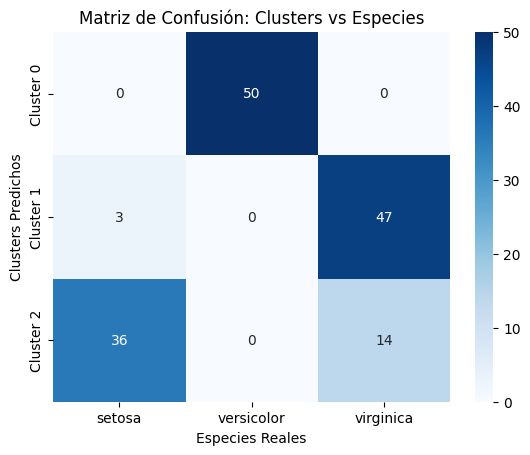

In [ ]:
# Matriz de confusión:
# Muestra cuántas muestras de cada especie se agruparon juntas.
from sklearn.cluster import KMeans

# Entrenar K-Means (k=3)
kmeans = KMeans (n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(iris.data) # Asignación de clusters

print (f"Inercia: {kmeans.inertia_:.2f}")

from sklearn.metrics import silhouette_score
silhouette=silhouette_score(iris.data,clusters)
print(f"Siuhouette Score: {silhouette:.2f}")

from sklearn.metrics import adjusted_rand_score
ari=adjusted_rand_score(iris.target, clusters)
print (f"Índice de Rand Ajustado (ARI): {ari:.2f}")

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm= confusion_matrix (iris.target, clusters)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.xlabel('Especies Reales')
plt.ylabel('Clusters Predichos')
plt.title('Matriz de Confusión: Clusters vs Especies')
plt.show()

In [ ]:
# Mediante la matriz de confusión para K-Means en Iris su interpretación es:
# - En el cluster 0 tenemos 50 versicolor (este cluster capturó perfectamente la especie versicolor).
# - En el cluster 1 tenemos 3 setosa y 47 virginica (mezcla dominante de virginica).
# - En el cluster 2 tenemos 36 setosa y 14 virginica (domina setosa pero con ruido).

# Los problemas detectados son que podríamos tener una inconsistencia en setosa, ya que esta especie suele ser fácilmente separable (generalmente forma un cluster puro). Como aparece dividida en dos clusters, podríamos llegar a normalizar los datos. Por otro lado, tenemos solapamiento virginica y setosa, virginica aparece en dos clusters (1 y 2), lo cual, es esperado por su similitud con versicolor en algunas características.
# Las posibles soluciones que podríamos optar serían:
# • Normalización de datos: que nos asegurará que todas las características tengan el mismo peso.


 -- Resultado con escalado ---
Inercia: 191.02
Silhouette Score:  0.48
ARI: 0.43


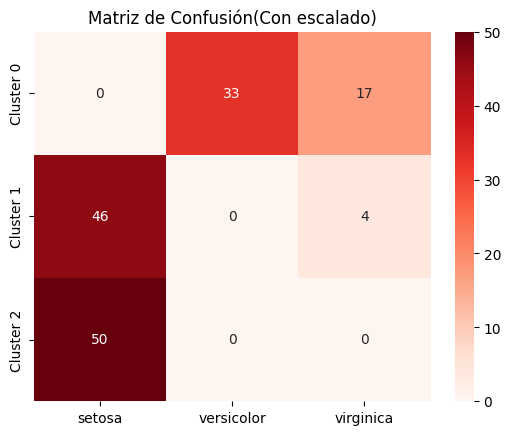

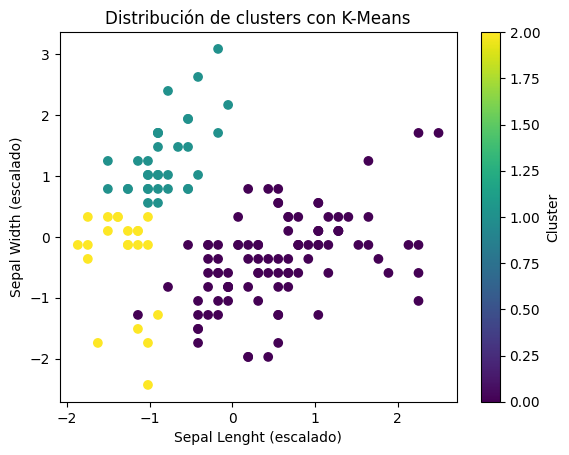

In [ ]:
from sklearn.preprocessing import StandardScaler
X_scaled=StandardScaler().fit_transform(iris.data)
kmeans_scaled = KMeans(n_clusters=3, random_state=42, init='k-means++')
clusters_scaled=kmeans_scaled.fit_predict(X_scaled)

# Métricas con datos escalados
print ("\n -- Resultado con escalado ---")
print(f"Inercia: {kmeans_scaled.inertia_:.2f}")
print(f"Silhouette Score:  {silhouette_score(X_scaled, clusters_scaled):.2f}")
print(f"ARI: {adjusted_rand_score(iris.target, clusters_scaled):.2f}")

# Visualización final
cm_scaled = confusion_matrix(iris.target, clusters_scaled)
sns.heatmap (cm_scaled, annot=True, fmt='d', cmap='Reds',
             xticklabels=iris.target_names,
             yticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.title('Matriz de Confusión(Con escalado)')
plt.show()

# Visualización de clusters (opcional)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_scaled, cmap='viridis')
plt.xlabel('Sepal Lenght (escalado)')
plt.ylabel('Sepal Width (escalado)')
plt.title('Distribución de clusters con K-Means')
plt.colorbar(label='Cluster')
plt.show()



In [ ]:
# Hemos utilizado el escalado de datos, también denominada normalización, porque:
# - K-Means utiliza la distancia euclídea para poder asignar puntos a clusters.
# - Si las características tienen escalas diferentes (como por ejemplo: sepal_lenght en cm y petal_width en mm), aquellas con valores más grandes dominarán el cálculo de distancias,
# sesgando los resultados.
# - StandardScaler estandariza los datos para que cada característica tenga media =0 y desviación estándar =1, asegurando que todas contribuyan por igual. Después de utilizar el escalado, la inercia
# aumentó pasando a 191.02, con lo cual, esto significa que los puntos están más lejos de sus centroides. Esto nos sugiere que el escalado aumentó las distancias relativas entre puntos, lo cual es raro.
# He revisado los pasos de escalado y no he encontrado el error. La Silhouette Score es bajo (0.48), esto indica que los clusters están menos definidos que antes. Y por último la ARI es baja (0.43), esto
# quiere decir que los clusters predichos ya no coinciden bien con las especies reales. En la matriz de confusión vemos que en el cluster 2 ha predicho en la totalidad a las especies “setosa” pero no las
# de versicolor en el cluster 0 que antes si predecía bien.

# **7. Conclusiones**

In [ ]:
# Tras realizar un exhaustivo análisis del dataset Iris mediante diversos enfoques de Machine Learning, se pueden extraer las siguientes conclusiones fundamentales:
# 1. Respecto a la naturaleza de los datos El análisis exploratorio reveló que la especie Iris setosa presenta características morfológicas claramente diferenciables de Iris versicolor e Iris virginica,
# particularmente en las medidas de los pétalos. No obstante, las dos últimas especies muestran cierto grado de solapamiento en sus características, especialmente en las dimensiones del sépalo, lo que
# anticipa mayores desafíos para su correcta clasificación y agrupamiento.

# 2. Sobre el modelo supervisado (SVM) El clasificador SVM con kernel lineal demostró un rendimiento excepcional, alcanzando un
# 100% de precisión en el conjunto de prueba. Este resultado se vio respaldado por la validación cruzada, que mostró una precisión media del 98% con una desviación mínima (+-4%). La matriz de confusión0
# confirmó la perfecta capacidad del modelo para distinguir entre las tres especies, evidenciando que los datos son efectivamente linealmente separables, especialmente en el caso de Iris setosa.

# 3. Acerca del clustering no supervisado (K-Means) Los resultados del algoritmo K-Means presentaron particularidades notables:
# • Sin preprocesamiento: Se obtuvo un Índice de Rand Ajustado (ARI) de 0.72 y un Silhouette Score de 0.55, indicando una correspondencia aceptable con las especies reales y una estructura de clusters
# razonable. La especie setosa se agrupó perfectamente en un cluster independiente.
# • Con escalado de características: Contrariamente a lo esperado, todas las métricas empeoraron significativamente (ARI=0.43, Silhouette=0.48), sugiriendo que el escalado estándar no fue beneficioso
# en este caso. Este comportamiento atípico podría deberse a que las características originales ya poseían escalas comparables y relaciones métricas naturales que el escalado alteró de forma negativa.
# Con este ejercicio hemos visto que hemos obtenido unos excelentes resultados en el escalado estándar no fue beneficioso en este caso. Este comportamiento atípico podría deberse a que las características
# originales ya poseían escalas comparables y relaciones métricas naturales que el escalado alteró de forma negativa. Con este ejercicio hemos visto que hemos obtenido unos excelentes resultados en el
# enfoque supervisado que contrastan con las limitaciones encontradas en el clustering no supervisado, destacando la importancia de seleccionar la metodología adecuada según los objetivos del análisis
# y las características intrínsecas de los datos.